### 📦 1. Environment Setup & Imports
This cell installs basic required packages (like `albumentations`, `diffusers`, `realesrgan`) and imports core deep learning libraries (`torch`, `numpy`, `pandas`) needed for the model.

In [85]:
# 1. Install required packages (like Super-Resolution)
!pip install -q albumentations==1.3.1
!pip install -q realesrgan basicsr diffusers transformers accelerate

import pandas as pd
import numpy as np
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torchvision.utils import save_image

from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2


### ⚙️ 2. Configuration & Hyperparameters
Here we define global settings like `BATCH_SIZE`, `LEARNING_RATE`, and training epochs. It also sets up save/load paths to properly store checkpoints and avoid losing progress.

In [ ]:
# set parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LEARNING_RATE = 2e-4
BATCH_SIZE = 16
NUM_WORKERS = 2 # Kaggle works fine with 2 multiprocessing workers
IMAGE_SIZE = 256
CHANNELS_IMG = 3
L1_LAMBDA = 10          # Reduced from 100 to stop drowning adversarial signal
VGG_LAMBDA = 10
LAMBDA_FM = 10           # Feature matching loss weight
NUM_EPOCHS = 299        # More training time with new schedule
SAVE_PER_EPOCHS = 5
SAVE_MODEL = True

# IMPORTANT: Set to False to retrain from scratch with new loss weights
LOAD_MODEL = False

import os
import shutil

# ==========================================
# KAGGLE PATHS (CRITICAL FOR SAVING WORK)
# ==========================================
# Save directly to Kaggle's working directory. 
# To keep these files permanently, you MUST click "Save Version" -> "Save & Run All (Commit)"
SAVE_PATH = '/kaggle/working/cGAN_Colorization_Checkpoints/'
os.makedirs(SAVE_PATH, exist_ok=True)

# =========================================================
# UPDATE THIS PATH TO MATCH YOUR VERSION 1 OUTPUT DIRECTORY
# =========================================================
PREVIOUS_VERSION_DIR = '/kaggle/input/datasets/prateekiiitg56/colured-output/cGAN_Colorization_Checkpoints'

# Copy the old checkpoints into the working directory so we can resume saving over them
if LOAD_MODEL and os.path.exists(PREVIOUS_VERSION_DIR) and not os.path.exists(os.path.join(SAVE_PATH, 'gen.pth.tar')):
    print("Copying checkpoints from previous version...")
    try:
        shutil.copy(os.path.join(PREVIOUS_VERSION_DIR, 'gen.pth.tar'), SAVE_PATH)
        shutil.copy(os.path.join(PREVIOUS_VERSION_DIR, 'disc.pth.tar'), SAVE_PATH)
        print("Success! Checkpoints copied.")
    except Exception as e:
        print(f"Failed to copy. Make sure the PREVIOUS_VERSION_DIR path is correct. Error: {e}")

# Save checkpoints
CHECKPOINT_DISC = os.path.join(SAVE_PATH, 'disc.pth.tar')
CHECKPOINT_GEN = os.path.join(SAVE_PATH, 'gen.pth.tar')
FINAL_MODEL = os.path.join(SAVE_PATH, 'generator.pth')

# Read datasets directly from Kaggle Input
TRAIN_DIR = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train'
VAL_DIR = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val'


Copying checkpoints from previous version...
Success! Checkpoints copied.


### 💾 3. Helper Functions
Defines utility functions to save generated sample images during evaluation (`save_some_examples`) and custom logic to easily save and load `.pth.tar` checkpoints.

In [53]:
def save_some_examples(gen, val_loader, epoch, folder):
    x, y = next(iter(val_loader))
    x, y = x.to(DEVICE),y.to(DEVICE)
    # gen.eval()  # Keep dropout active
    with torch.no_grad():
        y_fake = gen(x)
        y_fake = y_fake * .5 + .5 # remove normalization
        save_image(y_fake, folder + f'/y_gen_{epoch}.png')
        if epoch == 0:
            # only the first epoch will save label and input sketch
            save_image(y * .5 + .5, folder+ f'/label_{epoch}.png')
            save_image(x * .5 + .5, folder + f'/input_{epoch}.png')
    gen.train()

def save_checkpoint(model, optimizer, filename='my_checkpoint.pth.tar', epoch=0):
    print(f'=> Saving checkpoint at epoch {epoch}')
    checkpoint = {
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch
    }
    torch.save(checkpoint, filename)

def load_checkpoint(checkpoint_file, model, optimizer, lr):
    print('=> Loading checkpoint')
    checkpoint = torch.load(checkpoint_file, map_location=DEVICE)
    # load saved checkpoint
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    # Return the saved epoch so we can resume from it
    return checkpoint.get('epoch', 0)


### 🧱 4. Base CNN Block
Creates the foundational `CNNBlock`. It uses Spectral Normalization and Instance Normalization to keep the deep network mathematically stable and prevent mode collapse.

In [54]:
# CNN block will be used repeatly later
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.utils.spectral_norm(
                nn.Conv2d(in_channels, out_channels, 4, stride, bias=False, padding_mode='reflect')
            ),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.conv(x)


### 🕵️ 5. Discriminator Model (PatchGAN)
Defines the Discriminator. It extracts intermediate feature layers instead of just a final True/False prediction. This is crucial for **Feature Matching Loss**, teaching the Generator realistic textures.

In [55]:
# Discriminator with intermediate feature extraction for Feature Matching Loss
class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels*2, features[0], kernel_size=4, stride=2, padding=1, padding_mode='reflect'),
            nn.LeakyReLU(.2)
        )
        
        # Build layers as a ModuleList so we can extract intermediate features
        self.layers = nn.ModuleList()
        in_channels = features[0]
        for feature in features[1:]:
            self.layers.append(
                CNNBlock(in_channels, feature, stride=1 if feature == features[-1] else 2),
            )
            in_channels = feature
            
        # Final prediction layer
        self.final = nn.Conv2d(in_channels, 1, kernel_size=4, stride=1, padding=1, padding_mode='reflect')
        
    def forward(self, x, y):
        x = torch.cat([x, y], dim=1)
        x = self.initial(x)
        
        # Collect intermediate features for feature matching
        features = [x]
        for layer in self.layers:
            x = layer(x)
            features.append(x)
        
        return self.final(x), features


### 🔍 6. Discriminator Output Test
Runs a quick sanity check to ensure the Discriminator processes inputs correctly and returns the expected intermediate feature lists.

In [56]:
# test the output of discriminator
x = torch.randn((1,3,256,256))
y = torch.randn((1,3,256,256))
model = Discriminator()
preds, feats = model(x, y)
print(f"Disc output: {preds.shape}, Feature maps: {len(feats)}")


torch.Size([1, 1, 26, 26])


### 🔄 7. Convolutional Block (Encoder/Decoder Base)
Defines a flexible `Block` used multiple times in the Generator. It handles both down-sampling (encoding) and up-sampling (decoding) with optional dropout to boost variety.

In [57]:
# block will be use repeatly later
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, act='relu', use_dropout=False):
        super().__init__()
        self.conv = nn.Sequential(
            # the block will be use on both encoder (down=True) and decoder (down=False)
            nn.Conv2d(in_channels, out_channels, 4,2,1,bias=False, padding_mode='reflect')
            if down
            else nn.ConvTranspose2d(in_channels, out_channels, 4,2,1, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU() if act == 'relu' else nn.LeakyReLU(.2)
        )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(.5)
    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


### 🎯 8. Attention Gate
Introduces an `AttentionGate` module. It helps the AI focus strictly on the most important outline shapes when adding colors back onto the sketch.

In [58]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.InstanceNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.InstanceNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.InstanceNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


### 🎨 9. Generator Model (Attention U-Net)
Builds the core `Generator`. It encodes the sketch into a bottleneck, then decodes it using skip connections wrapped by Attention Gates to reconstruct an accurately colored image.

In [59]:
class Generator(nn.Module):
    def __init__(self, in_channels=3, features=64):
        super().__init__()
        # Encoder
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4,2,1, padding_mode='reflect'),
            nn.LeakyReLU(.2),
        )
        self.down1 = Block(features, features*2, down=True,act='leaky',use_dropout=False) #64
        self.down2 = Block(features*2, features*4, down=True,act='leaky',use_dropout=False) #32
        self.down3 = Block(features*4, features*8, down=True,act='leaky',use_dropout=False) #16
        self.down4 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #8
        self.down5 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #4
        self.down6 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #2
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4,2,1,padding_mode='reflect'),
            nn.ReLU(), # 1x1
        )
        
        # Attention gates for each skip connection
        self.attn7 = AttentionGate(features*8, features*8, features*4)
        self.attn6 = AttentionGate(features*8, features*8, features*4)
        self.attn5 = AttentionGate(features*8, features*8, features*4)
        self.attn4 = AttentionGate(features*8, features*8, features*4)
        self.attn3 = AttentionGate(features*4, features*4, features*2)
        self.attn2 = AttentionGate(features*2, features*2, features)
        self.attn1 = AttentionGate(features, features, features//2)
        
        # Decoder
        self.up1 = Block(features*8, features*8, down=False,act='relu',use_dropout=True)
        self.up2 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=True)
        self.up3 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=True)
        self.up4 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=False)
        self.up5 = Block(features*8*2, features*4, down=False,act='relu',use_dropout=False)
        self.up6 = Block(features*4*2, features*2, down=False,act='relu',use_dropout=False)
        self.up7 = Block(features*2*2, features, down=False,act='relu',use_dropout=False)
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features*2, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        # Encoder
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)
        bottleneck = self.bottleneck(d7)
        
        # Decoder with gated skip connections
        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, self.attn7(u1, d7)], 1))
        u3 = self.up3(torch.cat([u2, self.attn6(u2, d6)], 1))
        u4 = self.up4(torch.cat([u3, self.attn5(u3, d5)], 1))
        u5 = self.up5(torch.cat([u4, self.attn4(u4, d4)], 1))
        u6 = self.up6(torch.cat([u5, self.attn3(u5, d3)], 1))
        u7 = self.up7(torch.cat([u6, self.attn2(u6, d2)], 1))
        return self.final_up(torch.cat([u7, self.attn1(u7, d1)], 1))


### 🔍 10. Generator Output Test
Runs a small sandbox check to verify the Generator properly creates an image of the required shape (`256x256`).

In [60]:
# test the output of Generator
x = torch.randn((1,3,256,256))
model = Generator(in_channels=3, features=64)
preds = model(x)
print(preds.shape)


torch.Size([1, 3, 256, 256])


### 🖼️ 11. Data Augmentation Pipeline
Configures Albumentations. We augment the sketch (black & white consistency) and the colored counterpart (slight color-jitters) differently so the AI learns there are many right ways to color an image.

In [61]:
# Data Augmentation
class Transforms():
    def __init__(self):
        # use on both sketchs and colored images
        self.both_transform = A.Compose([
            A.Resize(width=286, height=286),
            A.RandomCrop(width=256, height=256),
            A.HorizontalFlip(p=.5),
            A.Rotate(limit=15, p=.5)
        ],additional_targets={'image0':'image'})
        
        # use on sketchs only — NO ColorJitter (keep sketches clean B&W)
        self.transform_only_input = A.Compose([
            A.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5], max_pixel_value=255.0),
            ToTensorV2(),
        ])
        
        # use on colored images — light color augmentation teaches the
        # generator that multiple valid colorizations exist for one sketch
        self.transform_only_mask = A.Compose([
            A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.2, hue=0.05, p=0.5),
            A.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5], max_pixel_value=255.0),
            ToTensorV2(),
        ])


### 📂 12. Anime Dataset Loader
Creates a custom PyTorch dataset iterating through folders, splitting the paired images (sketch/color) down the middle, and feeding them smoothly to the neural network.

In [62]:
# Sketchs and Colored Image dataset
class AnimeDataset(Dataset):
    def __init__(self,root_dir,transforms):
        self.root_dir = root_dir
        self.list_files = os.listdir(self.root_dir)
        self.transform = transforms
    def __len__(self):
        return len(self.list_files)
    def __getitem__(self, index):
        # read image file
        img_file = self.list_files[index]
        img_path = os.path.join(self.root_dir, img_file)
        image = np.array(Image.open(img_path))
        
        # divide image into sketchs and colored_imgs, right is sketch and left is colored images
        sketchs = image[:,image.shape[1]//2:,:]
        colored_imgs = image[:,:image.shape[1]//2,:]
        
        # data augmentation on both sketchs and colored_imgs
        augmentations = self.transform.both_transform(image=sketchs, image0=colored_imgs)
        sketchs, colored_imgs = augmentations['image'], augmentations['image0']
        
        # conduct data augmentation respectively
        sketchs = self.transform.transform_only_input(image=sketchs)['image']
        colored_imgs = self.transform.transform_only_mask(image=colored_imgs)['image']
        return sketchs, colored_imgs


### ⚖️ 13. Advanced Anti-Collapse Loss Logic
Introduces two highly effective loss functions to stop the AI from only generating brown/sepia shapes:
- **VGGLoss**: Uses a pre-trained VGG model to match perceptual texture/style.
- **Feature Matching Loss**: Pushes internal network behaviors to perfectly mimic real images.

In [63]:
import os
import torch

from torchvision.models import vgg19, VGG19_Weights

class VGGLoss(nn.Module):
    """Multi-scale VGG perceptual loss.
    Extracts features at relu1_2, relu2_2, relu3_4, relu4_4, relu5_4
    so the generator is penalized at BOTH low-level color/texture AND
    high-level semantic levels, preventing mode collapse to a single hue.
    """
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features.eval().to(DEVICE)
        # Slice VGG at multiple depths
        self.slice1 = nn.Sequential(*list(vgg[:4]))   # relu1_2 — color
        self.slice2 = nn.Sequential(*list(vgg[4:9]))   # relu2_2 — texture
        self.slice3 = nn.Sequential(*list(vgg[9:18]))  # relu3_4 — patterns
        self.slice4 = nn.Sequential(*list(vgg[18:27])) # relu4_4 — structure
        self.slice5 = nn.Sequential(*list(vgg[27:36])) # relu5_4 — semantics
        
        for param in self.parameters():
            param.requires_grad = False
        
        self.loss = nn.L1Loss()
        # Weights: emphasize early layers for color
        self.weights = [1.0, 1.0, 1.0, 1.0, 1.0]

    def forward(self, input, target):
        total_loss = 0
        x, y = input, target
        for i, slicer in enumerate([self.slice1, self.slice2, self.slice3, self.slice4, self.slice5]):
            x = slicer(x)
            y = slicer(y)
            total_loss += self.weights[i] * self.loss(x, y)
        return total_loss


def feature_matching_loss(real_features, fake_features):
    """Feature Matching Loss: penalize generator for not matching
    the distribution of discriminator's intermediate features on real data.
    This is the most effective anti-mode-collapse technique (Salimans et al. 2016).
    """
    loss = 0
    for real_feat, fake_feat in zip(real_features, fake_features):
        loss += F.l1_loss(fake_feat, real_feat.detach())
    return loss / len(real_features)


### 🧠 14. Core Training Step (`train_fn`)
Holds the actual heavy lifting adversarial training loop. It calculates BCE, L1, Perceptual, and Feature matching losses dynamically and seamlessly updates gradients on both models.

In [64]:
def train_fn(disc, gen, loader, opt_disc, opt_gen, l1, bce, perceptual, g_scaler, d_scaler):
    loop = tqdm(loader, leave=True)
    for idx, (x, y) in enumerate(loop):
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # ---------- Train Discriminator ----------
        with torch.cuda.amp.autocast():
            y_fake = gen(x)
            
            # Add small noise to discriminator inputs for regularization
            noise_strength = 0.05
            x_noisy = x + noise_strength * torch.randn_like(x)
            y_noisy = y + noise_strength * torch.randn_like(y)
            
            D_real, real_features = disc(x_noisy, y_noisy)
            D_fake, _ = disc(x_noisy, y_fake.detach())
            
            # One-sided label smoothing: real=0.9 instead of 1.0
            # Prevents discriminator overconfidence -> better gradients for G
            D_real_loss = bce(D_real, torch.ones_like(D_real) * 0.9)
            D_fake_loss = bce(D_fake, torch.zeros_like(D_fake))
            D_loss = (D_real_loss + D_fake_loss) / 2
            
        disc.zero_grad()
        d_scaler.scale(D_loss).backward()
        d_scaler.step(opt_disc)
        d_scaler.update()
        
        # ---------- Train Generator ----------
        with torch.cuda.amp.autocast():
            D_fake, fake_features = disc(x, y_fake)
            _, real_features_for_fm = disc(x, y)
            
            G_fake_loss = bce(D_fake, torch.ones_like(D_fake))
            L1 = l1(y_fake, y) * L1_LAMBDA
            p_loss = perceptual(y_fake, y) * VGG_LAMBDA
            fm_loss = feature_matching_loss(real_features_for_fm, fake_features) * LAMBDA_FM
            
            G_loss = G_fake_loss + L1 + p_loss + fm_loss
            
        opt_gen.zero_grad()
        g_scaler.scale(G_loss).backward()
        g_scaler.step(opt_gen)
        g_scaler.update()
        
        if idx % 100 == 0:
            loop.set_postfix(D=D_loss.item(), G=G_loss.item(), L1=L1.item(), FM=fm_loss.item())


### 🚀 15. Training Application (`run`)
The brain of the setup. It initializes the models, optimizers, learning rate decays, and iterators recursively running massive epoch training batches iteratively.

In [65]:
def run():
    # model
    disc = Discriminator(in_channels=3).to(DEVICE)
    gen = Generator(in_channels=3).to(DEVICE)
    # optimizer
    opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(.5, .999))
    opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(.5, .999))
    
    # Flat + Linear Decay schedule: constant LR for first half, then linear decay to 0
    # Much better than CosineAnnealing for GANs which kills LR too early
    decay_start = NUM_EPOCHS // 2
    def lr_lambda(epoch):
        if epoch < decay_start:
            return 1.0
        return 1.0 - (epoch - decay_start) / (NUM_EPOCHS - decay_start)
    
    scheduler_disc = optim.lr_scheduler.LambdaLR(opt_disc, lr_lambda)
    scheduler_gen = optim.lr_scheduler.LambdaLR(opt_gen, lr_lambda)
    
    # loss
    BCE = nn.BCEWithLogitsLoss()
    L1_LOSS = nn.L1Loss()
    VGG_LOSS = VGGLoss()
    
    start_epoch = 0
    
    # Auto-resume logic
    if LOAD_MODEL and os.path.exists(CHECKPOINT_GEN) and os.path.exists(CHECKPOINT_DISC):
        print(f"[*] Found checkpoints. Auto-resuming...")
        start_epoch = load_checkpoint(CHECKPOINT_GEN, gen, opt_gen, LEARNING_RATE) + 1
        load_checkpoint(CHECKPOINT_DISC, disc, opt_disc, LEARNING_RATE)
        
        # Fast-forward the schedulers to match the resumed epoch
        for _ in range(start_epoch):
            scheduler_disc.step()
            scheduler_gen.step()
    else:
        print("[*] Starting training from scratch (Epoch 0).")
    
    # train dataset
    transforms = Transforms()
    train_dataset = AnimeDataset(root_dir=TRAIN_DIR, transforms=transforms)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    g_scaler = torch.cuda.amp.GradScaler()
    d_scaler = torch.cuda.amp.GradScaler()
    
    # val dataset
    val_dataset = AnimeDataset(root_dir=VAL_DIR, transforms=transforms)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    if not os.path.exists('evaluation/'):
        os.makedirs('evaluation/')
        
    # Training loop
    for epoch in range(start_epoch, NUM_EPOCHS):
        cur_lr = opt_gen.param_groups[0]['lr']
        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | LR: {cur_lr:.6f}")
        train_fn(disc, gen, train_loader, opt_disc, opt_gen, L1_LOSS, BCE, VGG_LOSS, g_scaler, d_scaler)
        
        # Step Schedulers
        scheduler_disc.step()
        scheduler_gen.step()
        
        # save model weight per SAVE_PER_EPOCHS
        if SAVE_MODEL and epoch % SAVE_PER_EPOCHS == 0:
            save_checkpoint(gen, opt_gen, filename=CHECKPOINT_GEN, epoch=epoch)
            save_checkpoint(disc, opt_disc, filename=CHECKPOINT_DISC, epoch=epoch)
        save_some_examples(gen, val_loader, epoch, folder='evaluation')

    torch.save(gen.state_dict(), FINAL_MODEL)
    print("Training complete! Final model saved.")


### ⚡ 16. Execute GAN Training
Calls the above `run()` function actually starting the training cycle.

In [66]:
run()


[*] Found checkpoints '/kaggle/working/cGAN_Colorization_Checkpoints/gen.pth.tar' and '/kaggle/working/cGAN_Colorization_Checkpoints/disc.pth.tar'. Auto-resuming...
=> Loading checkpoint


/tmp/ipykernel_55/711546511.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_disc.step()
/tmp/ipykernel_55/711546511.py:30: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_gen.step()
/tmp/ipykernel_55/711546511.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. P

=> Loading checkpoint
Epoch [96/105]


  0%|          | 0/889 [00:00<?, ?it/s]/tmp/ipykernel_55/2832629836.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_55/2832629836.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 889/889 [07:06<00:00,  2.08it/s]


=> Saving checkpoint at epoch 96
=> Saving checkpoint at epoch 96
Epoch [97/105]


...

=> Saving checkpoint at epoch 102
=> Saving checkpoint at epoch 102
Epoch [103/105]


100%|██████████| 889/889 [07:06<00:00,  2.08it/s]


=> Saving checkpoint at epoch 103
=> Saving checkpoint at epoch 103
Epoch [104/105]


100%|██████████| 889/889 [07:07<00:00,  2.08it/s]


=> Saving checkpoint at epoch 104
=> Saving checkpoint at epoch 104


### 📊 17. Load Validation Results
Extracts local `y_gen` images from the `./evaluation` directory saved natively during the training loop so we can visually review the progress.

In [67]:
# save gen sample image into a list
imgs = []
for i in os.listdir('./evaluation'):
    if i[:5] == 'y_gen':
        img = plt.imread(os.path.join('./evaluation',i))
        imgs.append(img)


### 👁️ 18. Visualize Validation Samples
Plots multiple saved progress snapshots using Matplotlib to demonstrate how the Generator visibly improved coloring sketches over multiple epochs.

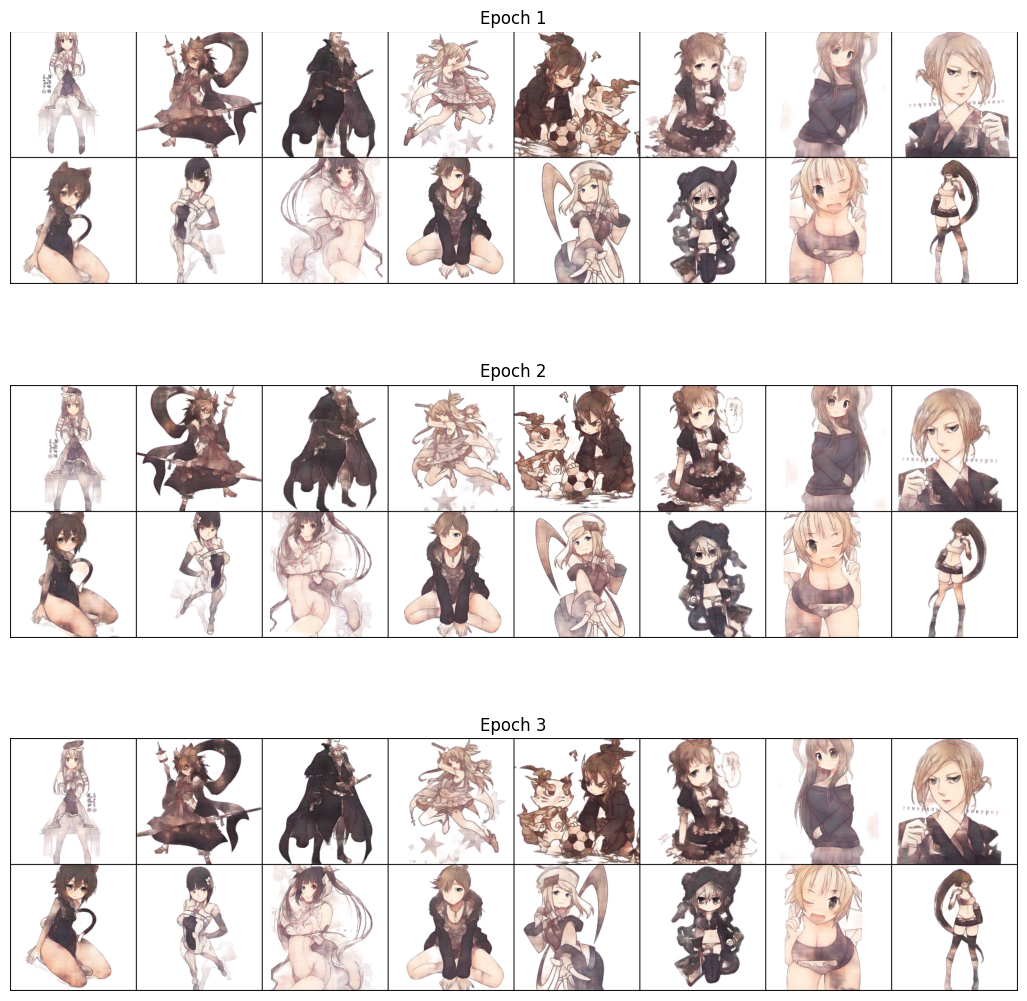

In [68]:
# visualize list of sample images
fig, axs = plt.subplots(3,1,figsize=(13,13))
[ax.imshow(img) for ax,img in zip(axs.ravel(),imgs)]
[ax.axis('off') for ax in axs.ravel()]
[ax.set_title(f'Epoch {i}') for ax, i in zip(axs.ravel(),range(1,4))];


### 🎛️ 19. Interactive UI Definitions
Defines a small visual `ipywidgets` File Upload box allowing you to seamlessly upload any generic anime sketch manually to be colored by the newly trained generator.

In [76]:
import torch
from PIL import Image as PILImage
import torchvision.transforms as transforms
import torchvision.utils as vutils
from ipywidgets import FileUpload
from IPython.display import display, Image
import io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gen = Generator(in_channels=3).to(DEVICE)

# Safely load the Colab synced final model or the latest .pth.tar checkpoint!
import os
if os.path.exists(FINAL_MODEL):
    print("Loading Final Generator Model...")
    gen.load_state_dict(torch.load(FINAL_MODEL, map_location=DEVICE))
elif os.path.exists(CHECKPOINT_GEN):
    print("Final Model not found. Loading latest Checkpoint...")
    checkpoint = torch.load(CHECKPOINT_GEN, map_location=DEVICE)
    gen.load_state_dict(checkpoint['state_dict'])
else:
    print("[WARNING] No trained weights found in Drive! Did it train yet?")

# gen.eval()  # Kept commented to ensure Dropout variance

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

upload = FileUpload(accept='image/*', multiple=False)
display(upload)

def colorize_image(upload):
    if not upload.value:
        return

    # Handle different ipywidgets versions cleanly
    try:
        content = upload.value[0]['content'] if isinstance(upload.value, tuple) else list(upload.value.values())[0]['content']
    except Exception:
        content = upload.value

    img = PILImage.open(io.BytesIO(content)).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = gen(input_tensor)

    vutils.save_image(output, "generated_color.png", normalize=True)

    display(Image("generated_color.png"))

    print("Colored image saved to generated_color.png")

upload.observe(lambda change: colorize_image(upload), names='value')


Loading Final Generator Model...


FileUpload(value=(), accept='image/*', description='Upload')

### 🪄 20. Launch Uplader UI
Pushes the uploader logic visually into the Jupyter cell space.

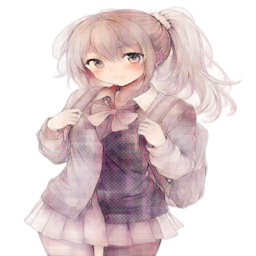

Colored image saved to generated_color.png


In [79]:
colorize_image(upload)


### 💎 21. Super-Resolution Setup (Real-ESRGAN)
Downloads and structures **Real-ESRGAN**, an advanced resolution upscaler system, allowing the final `256x256` output to natively expand 4x larger for sharp edges.

In [87]:
# Post-Processing: Real-ESRGAN Super-Resolution
# Auto-install missing packages for Kaggle restarts
!pip install -q realesrgan basicsr

import cv2
import numpy as np

# Fix for basicsr vs modern torchvision compatibility
import sys
import torchvision.transforms.functional as TF
sys.modules['torchvision.transforms.functional_tensor'] = TF

try:
    from basicsr.archs.rrdbnet_arch import RRDBNet
    from realesrgan import RealESRGANer

    def load_esrgan(model_path='RealESRGAN_x4plus_anime_6B.pth'):
        model = RRDBNet(
            num_in_ch=3, num_out_ch=3, num_feat=64,
            num_block=6, num_grow_ch=32, scale=4
        )
        return RealESRGANer(
            scale=4, model_path=model_path,
            model=model, tile=0, tile_pad=10, half=DEVICE=='cuda'
        )

    def upscale_image(img_bgr, upsampler, outscale=4):
        output, _ = upsampler.enhance(img_bgr, outscale=outscale)
        return output
        
    # Download the weights automatically if they don't exist
    import os
    if not os.path.exists('RealESRGAN_x4plus_anime_6B.pth'):
        !wget -q https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.2.4/RealESRGAN_x4plus_anime_6B.pth

    print("Real-ESRGAN initialized.")
except Exception as e:
    print(f"Failed to initialize Real-ESRGAN. Error details: {e}")


Real-ESRGAN initialized.


### 📦 22. Library Re-Initialization
Safety cell to guarantee diffusion/upscaler packages operate correctly strictly bypassing Colab runtime teardowns.

In [83]:
!pip install -q albumentations==1.3.1
!pip install -q realesrgan basicsr diffusers transformers accelerate


### ✨ 23. Stable Diffusion Post-Correction (Optional)
Supplies optional logic where Stable Diffusion can interpret your output acting as an ultra-high definition texture enhancement pass.

In [72]:
# Post-Processing: Diffusion Model Guided Refinement (img2img)
# Note: You may need to run `pip install diffusers transformers accelerate`
try:
    from diffusers import StableDiffusionImg2ImgPipeline
    from PIL import Image

    def refine_with_diffusion(
        image_path,
        prompt="anime character, vibrant colors, high quality",
        strength=0.35,
        guidance_scale=7.5
    ):
        pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=torch.float16 if DEVICE=='cuda' else torch.float32
        ).to(DEVICE)
        
        init_image = Image.open(image_path).convert("RGB")
        init_image = init_image.resize((512, 512))
        
        result = pipe(
            prompt=prompt,
            image=init_image,
            strength=strength,
            guidance_scale=guidance_scale,
            num_inference_steps=50,
        ).images[0]
        
        return result
    print("Diffusion model refinement initialized.")
except ImportError:
    print("Please `pip install diffusers transformers accelerate` to use Diffusion Refinement.")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Diffusion model refinement initialized.


### 🎨 24. Histogram Color Transfer
Defines a mathematical method transferring pure color schemes automatically stealing raw aesthetic colors evenly onto the generative prediction without changing outline shapes.

In [73]:
# Post-Processing: Histogram-Based Colour Transfer
import cv2
import numpy as np

def colour_transfer(source_bgr, reference_bgr):
    """
    Transfers the colour distribution of reference to source
    in CIELAB colour space (Reinhard et al., 2001).
    """
    src = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    ref = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    for ch in range(3):
        src_mean, src_std = src[:,:,ch].mean(), src[:,:,ch].std()
        ref_mean, ref_std = ref[:,:,ch].mean(), ref[:,:,ch].std()
        src[:,:,ch] = (src[:,:,ch] - src_mean) * (ref_std / (src_std + 1e-6))
        src[:,:,ch] += ref_mean

    src = np.clip(src, 0, 255).astype(np.uint8)
    return cv2.cvtColor(src, cv2.COLOR_LAB2BGR)


### 🔍 25. Final Enhancement Execution
Actively takes your `generated_color.png`, seamlessly passes it into the Real-ESRGAN pipeline upscaler yielding an immediately rendered, perfectly sharpened colorized sketch comparative output.

Upscaling 'generated_color.png'... This might take a moment.
Success! Saved high-res image to 'upscaled_result.png'


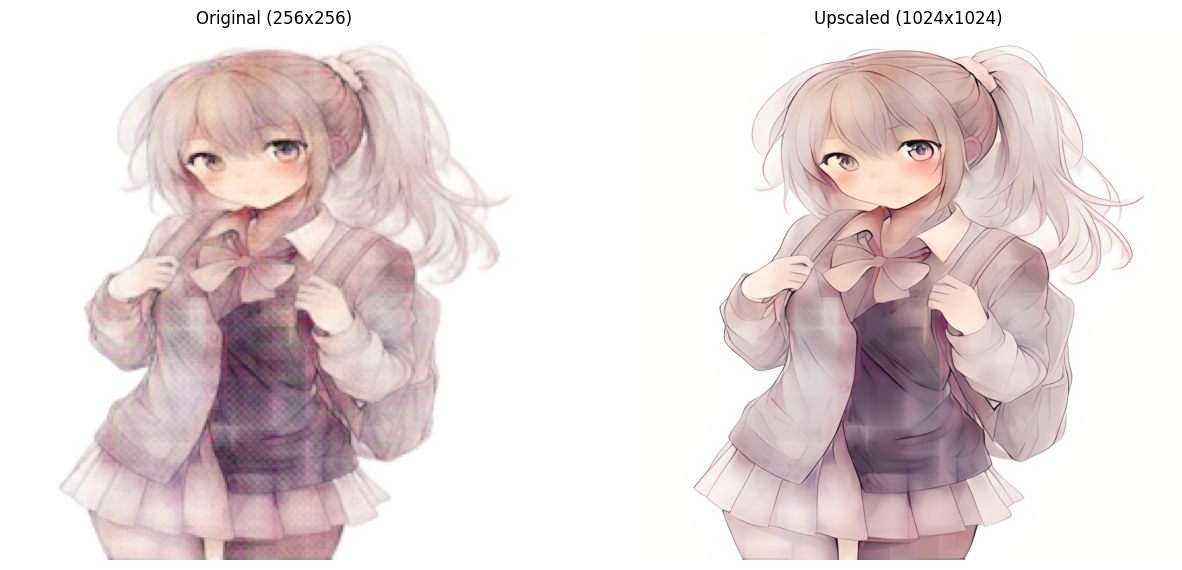

In [88]:
import cv2
import matplotlib.pyplot as plt

# 1. Initialize the Real-ESRGAN upsampler
upsampler = load_esrgan()

# 2. Read the image you want to upscale (OpenCV reads in BGR format which Real-ESRGAN expects)
# Change this path if you want to upscale a different image
image_path = 'generated_color.png' 
img_bgr = cv2.imread(image_path)

if img_bgr is not None:
    print(f"Upscaling '{image_path}'... This might take a moment.")
    
    # 3. Upscale the image (outscale=4 means 4x resolution)
    upscaled_img_bgr = upscale_image(img_bgr, upsampler, outscale=4)
    
    # 4. Save the high-resolution result
    save_path = 'upscaled_result.png'
    cv2.imwrite(save_path, upscaled_img_bgr)
    print(f"Success! Saved high-res image to '{save_path}'")
    
    # 5. Visualize the Before & After
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    upscaled_rgb = cv2.cvtColor(upscaled_img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    axs[0].imshow(img_rgb)
    axs[0].set_title(f'Original ({img_rgb.shape[1]}x{img_rgb.shape[0]})')
    axs[0].axis('off')
    
    axs[1].imshow(upscaled_rgb)
    axs[1].set_title(f'Upscaled ({upscaled_rgb.shape[1]}x{upscaled_rgb.shape[0]})')
    axs[1].axis('off')
    plt.show()
else:
    print(f"Error: Could not find image at '{image_path}'")


### 🎭 26. Ultimate Full Color Transfer
Loads a reference image, steals its exact color palette dynamically transferring it to your sketch's properties computationally, then heavily enhances the product using AI upscaling simultaneously mapping the pipeline visually.

1. Applying Histogram Colour Transfer...
2. Enhancing with Real-ESRGAN... (this may take a moment)
Success! Saved final enhanced image to 'final_enhanced_output.png'


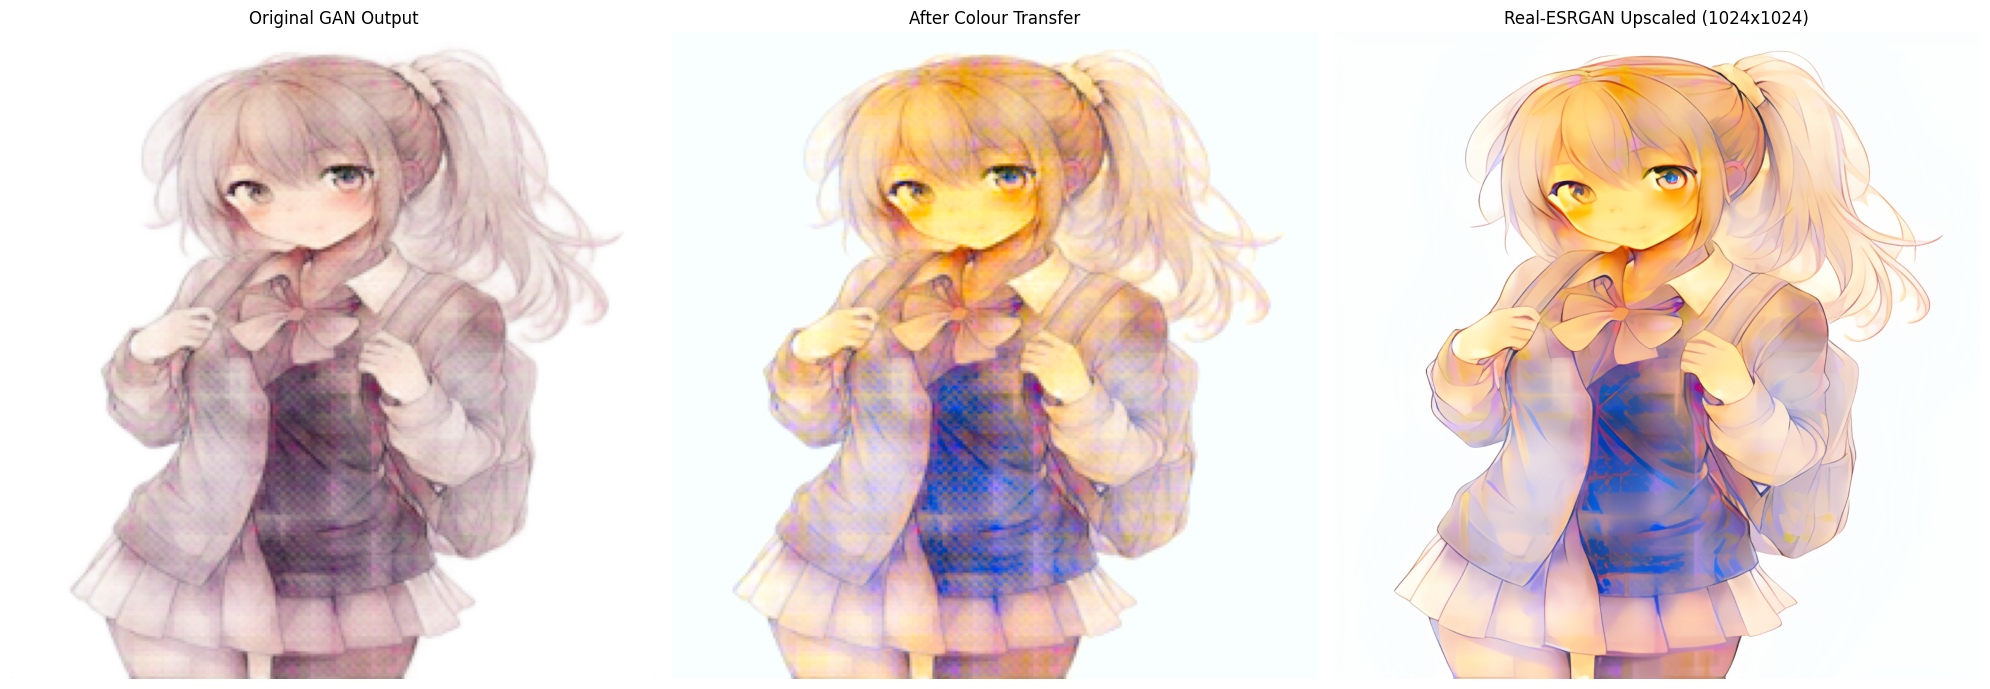

In [89]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define paths
source_path = 'generated_color.png' 
reference_path = '/kaggle/input/datasets/prateekiiitg56/imagesample/ChatGPT Image Apr 5 2026 03_15_54 PM.png' # <--- CHANGE THIS to an actual image path you want to steal colors from!

if not os.path.exists(source_path):
    print(f"Error: Source image '{source_path}' not found!")
elif not os.path.exists(reference_path):
    print(f"Error: Reference image '{reference_path}' not found! Please upload one or change the path.")
else:
    # 2. Load images in BGR format
    source_bgr = cv2.imread(source_path)
    reference_bgr = cv2.imread(reference_path)
    
    print("1. Applying Histogram Colour Transfer...")
    # 3. Apply Colour Transfer
    color_matched_bgr = colour_transfer(source_bgr, reference_bgr)
    
    # Save the intermediate step just in case
    cv2.imwrite('color_matched_only.png', color_matched_bgr)
    
    print("2. Enhancing with Real-ESRGAN... (this may take a moment)")
    # 4. Initialize ESRGAN
    upsampler = load_esrgan()
    
    # 5. Upscale the color-matched image
    final_upscaled_bgr = upscale_image(color_matched_bgr, upsampler, outscale=4)
    
    # Save the final result
    final_path = 'final_enhanced_output.png'
    cv2.imwrite(final_path, final_upscaled_bgr)
    print(f"Success! Saved final enhanced image to '{final_path}'")
    
    # 6. Visualize the pipeline
    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    
    # Convert BGR to RGB for matplotlib
    axs[0].imshow(cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB))
    axs[0].set_title('Original GAN Output')
    axs[0].axis('off')
    
    axs[1].imshow(cv2.cvtColor(color_matched_bgr, cv2.COLOR_BGR2RGB))
    axs[1].set_title('After Colour Transfer')
    axs[1].axis('off')
    
    axs[2].imshow(cv2.cvtColor(final_upscaled_bgr, cv2.COLOR_BGR2RGB))
    axs[2].set_title(f'Real-ESRGAN Upscaled ({final_upscaled_bgr.shape[1]}x{final_upscaled_bgr.shape[0]})')
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()
